In [1]:
from myutils import *
from scipy.optimize import minimize
from src import *

from scipy.special import erf, factorial

In [2]:
freq_list = np.linspace(0.1, 0.4, 61)

sampling_rate = 20
pic_time = (1 / (sampling_rate * freq_list) / 2 * 1e6).astype(int)

# Consider rounding errors
real_freq_list = 1 / (pic_time * 2) * 1e6 / sampling_rate

np.random.normal(6e-3, 8e-4) 可能差不多, 还有 (6e-3, 280e-6)

pic_time 可能有一个误差, 10us似乎合适

np.random.normal(3e-3, 0.3e-3) 非常像, (2.8e-3, 0.5e-3)也像

In [6]:
@parallelize()
def main(f, measurement, A):
    cropped, noise = [], []
    for _ in range(200):
        meta = MetaData(measurement, f, A, 0)
        meta_ = MetaData(measurement, np.round(f, 3), A, 0) # MetaData for save file, match the experiments.
        sim = Simulator(meta, delay=1e-6+np.random.normal(2.8e-3, 0.48e-3), waveform='sign')
        cropped_, noise_ = sim.gen()
        cropped.append(cropped_)
        noise.append(noise_)
    c = Estimates(np.array(cropped), meta_, noise=np.array(noise).mean(-1))
    return Estimation.FromEstimates(c)

In [5]:
for i in tqdm(real_freq_list):
    c = main(i, 'DI', 3*DMD.PIXEL_SIZE/2)

100%|██████████| 61/61 [02:32<00:00,  2.50s/it]


In [7]:
cs_di, cs_spade = main(real_freq_list, 'DI', 3*DMD.PIXEL_SIZE/2), main(real_freq_list, 'SPADE', 3*DMD.PIXEL_SIZE/2)

In [ ]:
raise

In [9]:
for i in range(61):
    cs_di[i].savez('__simulations__/di_3px')
    cs_spade[i].savez('__simulations__/spade_3px')

In [10]:
size = 9
(size / 2.54, size / 2.54 / 3 * 2)

(3.543307086614173, 2.3622047244094486)

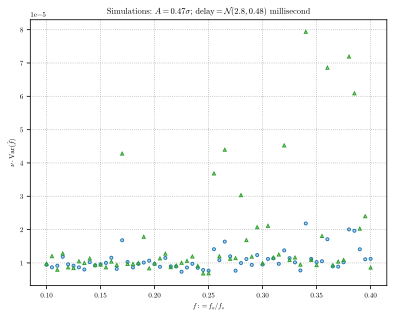

In [11]:
plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'


# di_x = [cs[i].metadata.ground_truth for i in range(61)]
di_y = [cs_di[i].frequency_estimates.var() * cs_di[i].photons.mean() for i in range(61)]
spade_y = [cs_spade[i].frequency_estimates.var() * cs_spade[i].photons.mean() for i in range(61)]

plt.plot(freq_list, spade_y, 
        marker='o', linestyle='', markersize=3,
        markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

plt.plot(freq_list, di_y,
        marker='^', linestyle='', markersize=3,
        markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

plt.grid(True, linestyle=':')
plt.title(r'Simulations: $A = 0.47\sigma$; ${\rm delay} =\mathcal{N}(2.8, 0.48)$ millisecond')
plt.xlabel(r'$f := f_o / f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.show()

In [ ]:
raise

RuntimeError: No active exception to reraise

In [2]:
meta = MetaData('SPADE', 0.2, 'frequency', 3*DMD.PIXEL_SIZE/2, 0, ('zhou2023', 'lse'))
sim = Simulator(meta, waveform='sign')
simdata = np.array([sim.gen() for _ in range(200)])

In [10]:
td1 = td_estimator('spade', simdata[:, 0, :, :], simdata[:, 1, :, :], 'mle', True)
td2 = td_estimator('spade', simdata[:, 0, :, :], simdata[:, 1, :, :], 'lse', True)
td3 = td_estimator('spade', simdata[:, 0, :, :], simdata[:, 1, :, :], 'zhou2023', True)
td4 = td_estimator('spade', simdata[:, 0, :, :], simdata[:, 1, :, :], 'sub', True)

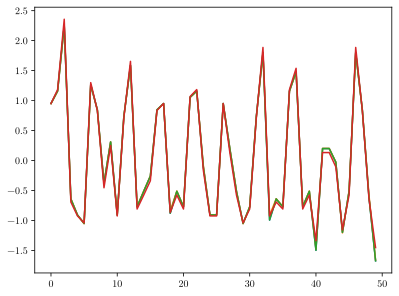

In [11]:
plot(td1[0])
plot(td2[0])
plot(td3[0])
plot(td4[0])

In [16]:
sp.stats.poisson(30).pmf(0)

9.357622968840175e-14

In [32]:
for wave in ('sign', 'sin'):
    @parallelize()
    def main(freq, repeat=200):
        meta = MetaData('SPADE', freq, 'frequency', 3*DMD.PIXEL_SIZE/2, 0, ('lse', 'lse'))
        sim = Simulator(meta, waveform=wave)
        simdata = np.array([sim.gen() for _ in range(repeat)])
        cropped_data, background = simdata[:, 0, :, :], simdata[:, 1, :, :]
        c = Estimates(cropped_data, meta, background=background.mean(-1))
        return Estimation.FromEstimates(c).estimates_a

    f_est = main(np.linspace(0.1, 0.4, 3001)[2200 : 2400])
    np.save(f'spade_{wave}_lse.npy', np.array(f_est))
    # for i in range(10):
        # f_est[i].savez('__sim__/')


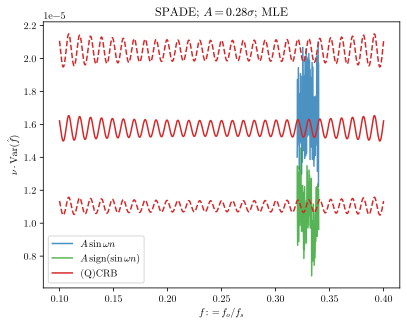

In [35]:
# f_est = np.load(r'__simulations__/common/spade_sin_mle.npy')
f_est = np.load(r'spade_sin_lse.npy')
plt.plot(np.linspace(0.1, 0.4, 3001)[2200 : 2400], f_est.var(-1) * 60, label=r'$A\,\sin\omega n$', alpha=0.8)

# f_est = np.load(r'__simulations__/common/spade_sign_mle.npy')
f_est = np.load(r'spade_sign_lse.npy')
plt.plot(np.linspace(0.1, 0.4, 3001)[2200 : 2400], f_est.var(-1) * 60, label=r'$A\,{\rm sign}(\sin\omega n)$', alpha=0.8, color='C2')


x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([3 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plt.plot(x_axis, crb, 'C3-', label='(Q)CRB')
plt.plot(x_axis, 1.3 * crb, 'C3--')
plt.plot(x_axis, 0.7 * crb, 'C3--')


plt.title(r'SPADE; $A= 0.28\sigma$; MLE')
plt.xlabel(r'$f:=f_o/f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
# plt.axvline(1/3)
plt.legend()
plt.show()

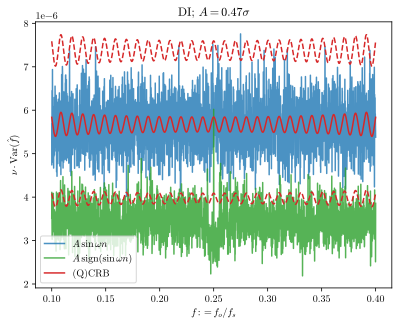

In [8]:
f_est = np.load(r'di_sin_mle.npy')
plt.plot(np.linspace(0.1, 0.4, 3001), f_est.var(-1) * 400, label=r'$A\,\sin\omega n$', alpha=0.8)

f_est = np.load(r'di_sign_mle.npy')
plt.plot(np.linspace(0.1, 0.4, 3001), f_est.var(-1) * 400, label=r'$A\,{\rm sign}(\sin\omega n)$', alpha=0.8, color='C2')


x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plt.plot(x_axis, crb, 'C3-', label='(Q)CRB')
plt.plot(x_axis, 1.3 * crb, 'C3--')
plt.plot(x_axis, 0.7 * crb, 'C3--')


plt.title(r'DI; $A= 0.47\sigma$')
plt.xlabel(r'$f:=f_o/f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.legend()
plt.show()

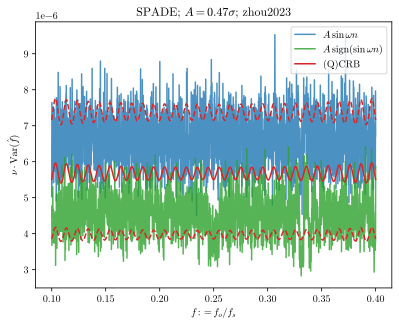

In [ ]:
f_est = np.load(r'__simulations__\common\spade_sin_zhou2023.npy')
plt.plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 60, label=r'$A\,\sin\omega n$', alpha=0.8)

f_est = np.load(r'__simulations__\common\spade_sign_zhou2023.npy')
plt.plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 60, label=r'$A\,{\rm sign}(\sin\omega n)$', alpha=0.8, color='C2')


x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plt.plot(x_axis, crb, 'C3-', label='(Q)CRB')
plt.plot(x_axis, 1.3 * crb, 'C3--')
plt.plot(x_axis, 0.7 * crb, 'C3--')


plt.title(r'SPADE; $A= 0.47\sigma$; zhou2023')
plt.xlabel(r'$f:=f_o/f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.legend()
plt.show()

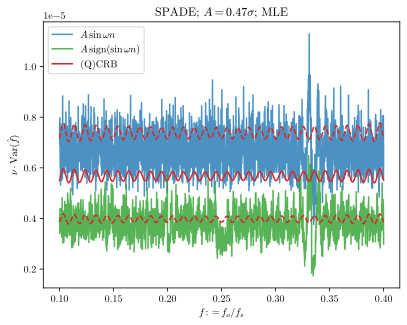

In [ ]:
f_est = np.load(r'__simulations__\common\spade_sin_mle.npy')
plt.plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 60, label=r'$A\,\sin\omega n$', alpha=0.8)

f_est = np.load(r'__simulations__\common\spade_sign_mle.npy')
plt.plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 60, label=r'$A\,{\rm sign}(\sin\omega n)$', alpha=0.8, color='C2')


x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plt.plot(x_axis, crb, 'C3-', label='(Q)CRB')
plt.plot(x_axis, 1.3 * crb, 'C3--')
plt.plot(x_axis, 0.7 * crb, 'C3--')


plt.title(r'SPADE; $A= 0.47\sigma$; MLE')
plt.xlabel(r'$f:=f_o/f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.legend()
plt.show()

$$
\frac{n1- n2}{ns} = \frac s\sigma exp(-s^2 / 4\sigma^2)
$$

$$
s\to 0; noise = 0
$$

$$
s = \sigma\frac{n1-n2}{n1+n2}
$$